In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

            AAPL_Adjclose  TSLA_Adjclose  WMT_Adjclose  SPY_Adjclose  \
Date                                                                   
2019-02-28      41.296989      21.325333     29.659931    249.943710   
2019-03-31      45.303856      18.657333     29.379719    254.467819   
2019-04-30      47.860622      15.912667     30.979290    264.863495   
2019-05-31      41.915714      12.344000     30.719877    247.972855   
2019-06-30      47.386524      14.897333     33.460571    265.228424   

            AAPL_returns  TSLA_returns  WMT_returns  SPY_returns  
Date                                                              
2019-02-28      0.043803      0.041033     0.032443     0.031901  
2019-03-31      0.092603     -0.133656    -0.009492     0.017939  
2019-04-30      0.054901     -0.159124     0.053014     0.040040  
2019-05-31     -0.132632     -0.253945    -0.008409    -0.065895  
2019-06-30      0.122677      0.188012     0.085458     0.067272  

Total observations: 71

B

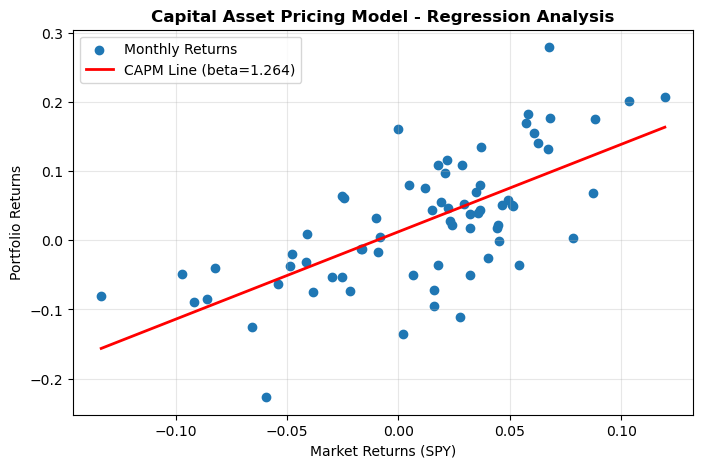

In [4]:
# Market interest rate
risk_free_rate = 0.01
# Monthly return to calculate the annual return
months_per_annual = 12

#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%#

# Capital Asset Pricing Model
class CAPM_MODEL():
    def __init__(self, mult_stocks, start_date, end_date):
        self.data = None
        self.mult_stocks = mult_stocks
        self.start_date = start_date
        self.end_date = end_date
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%#
    # Download the data from Yahoo Finance
    def download_data(self):
        data = {}
        for stock in self.mult_stocks:
            ticker = yf.download(stock, self.start_date, self.end_date,
                                 auto_adjust=True, progress=False)
            if 'Close' in ticker:
                series = ticker['Close'].squeeze()
                if not series.empty:
                    data[stock] = series
        return pd.DataFrame(data)
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%#
    def resample_monthly(self):
        df = self.download_data()
        df = df.resample('ME').last()
        
        # Dynamic column naming
        self.data = pd.DataFrame({f'{stock}_Adjclose': df[stock] for stock in self.mult_stocks})
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%#
    # Returns
    def monthly_returns(self):
        # Calculate returns for all stocks dynamically
        returns_cols = {}
        for stock in self.mult_stocks:
            adj_col = f'{stock}_Adjclose'
            returns_cols[f'{stock}_returns'] = np.log(self.data[adj_col] / self.data[adj_col].shift(1))
        
        self.data = pd.DataFrame(self.data)
        for col, returns in returns_cols.items():
            self.data[col] = returns
        
        self.data = self.data.dropna()
        print(self.data.head())
        print(f"\nTotal observations: {len(self.data)}")

        
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%#
    # Calculate beta
    def beta_CAPM_formula(self):
        # Get all asset returns (excluding the market index which is last)
        asset_returns_cols = [f'{stock}_returns' for stock in self.mult_stocks[:-1]]
        market_returns_col = f'{self.mult_stocks[-1]}_returns'
        
        returns_matrix = self.data[asset_returns_cols + [market_returns_col]].to_numpy().T
        cov_matrix = np.cov(returns_matrix)
        market_variance = cov_matrix[-1, -1]
        beta_capm = cov_matrix[:-1, -1] / market_variance

        # Create portfolio weights
        weights = np.random.dirichlet(np.ones(len(beta_capm)))
        port_beta = np.dot(weights, beta_capm)
        print(f"\nBetas for individual assets: {beta_capm}")
        print(f"Beta parameter using CAPM formula: {port_beta:.4f}")
        
        self.regression(weights)
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%#
    # Regression model
    def regression(self, weights):
        asset_returns_cols = [f'{stock}_returns' for stock in self.mult_stocks[:-1]]
        asset_returns = self.data[asset_returns_cols].to_numpy()
        port_return = np.dot(asset_returns, weights)
        
        market_returns_col = f'{self.mult_stocks[-1]}_returns'
        market_returns = self.data[market_returns_col].to_numpy()
        
        beta, alpha = np.polyfit(market_returns, port_return, deg=1)
        
        # Annualize the market return properly
        monthly_market_return = market_returns.mean()
        annual_market_return = (1 + monthly_market_return) ** months_per_annual - 1
        expected_return = risk_free_rate + beta * (annual_market_return - risk_free_rate)
        
        print(f"\nBeta parameter using regression model: {beta:.4f}")
        print(f"Alpha (intercept): {alpha:.6f}")
        print(f"Monthly market return (avg): {monthly_market_return:.4f}")
        print(f"Annual market return: {annual_market_return:.4f}")
        print(f"Risk-free rate: {risk_free_rate:.4f}")
        print(f"Expected portfolio return (CAPM): {expected_return:.4f}")
        
        self.regression_visualisation(beta, alpha, port_return, market_returns)
        
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%#
    # Regression visualisation
    def regression_visualisation(self, beta, alpha, port_return, market_returns):
        plt.figure(figsize=(8, 5))
        plt.scatter(market_returns, port_return, label="Monthly Returns")
        x_line = np.array([market_returns.min(), market_returns.max()])
        y_line = beta * x_line + alpha
        plt.plot(x_line, y_line, color='red', linewidth=2, label=f"CAPM Line (beta={beta:.3f})")
        plt.title("Capital Asset Pricing Model - Regression Analysis", weight="bold", fontsize=12)
        plt.xlabel("Market Returns (SPY)", fontsize=10)
        plt.ylabel("Portfolio Returns", fontsize=10)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        
if __name__ == "__main__":
    capm = CAPM_MODEL(['AAPL', 'TSLA', 'WMT', 'SPY'], "2019-01-01", "2025-01-01")
    capm.resample_monthly()
    capm.monthly_returns()
    capm.beta_CAPM_formula()